In [ ]:
import os
import glob
import pandas as pd
import numpy as np

from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [25]:
# Path where all worker folders are stored
BASE_DIR = "/home/amanda/Desktop/Fine-Tuning-Diffusion-Models-With-RL/dummy_workers"  # change to your main directory containing worker_0, worker_1, etc.
CSV_PATTERN = "worker_*/scores_per_image_timestep.csv"

csv_files = glob.glob(os.path.join(BASE_DIR, CSV_PATTERN))
print(f"Found CSVs: {csv_files}")

# Load all CSVs and concatenate
all_data = []
offset = 0
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    # Reindex images to make them unique across workers
    if df["image_idx"].notnull().any():
        df.loc[df["image_idx"].notnull(), "image_idx"] += offset
    # Compute offset: max image_idx in this df + 1
    if df["image_idx"].notnull().any():
        offset = df["image_idx"].max() + 1
    all_data.append(df)

all_data = pd.concat(all_data, ignore_index=True)

Found CSVs: ['/home/amanda/Desktop/Fine-Tuning-Diffusion-Models-With-RL/dummy_workers/worker_0/scores_per_image_timestep.csv', '/home/amanda/Desktop/Fine-Tuning-Diffusion-Models-With-RL/dummy_workers/worker_1/scores_per_image_timestep.csv']


# Define metrics

In [26]:
def avg_deviation_at_timestep(df: pd.DataFrame, timestep: int, metric_col: str = "reward") -> float:
    """
    Compute the average deviation of a metric for a given timestep.

    Args:
        df: DataFrame with columns ['timestep', 'image_idx', 'sample_idx', metric_col]
        timestep: the timestep to compute the deviation for
        metric_col: metric column name (default: 'reward')

    Returns:
        float: average deviation Δ(metric) at the given timestep
    """
    # Original metric values (sample_idx is None)
    orig_metrics = df[df["sample_idx"].isnull()].set_index("image_idx")[metric_col].to_dict()
    
    # Keep only denoised samples at the specified timestep
    t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == timestep)]
    
    delta_list = []
    for img_idx in t_df["image_idx"].unique():
        samples = t_df[t_df["image_idx"] == img_idx][metric_col].values
        orig_value = orig_metrics[img_idx]
        delta_list.append(np.mean(np.abs(samples - orig_value)))

    return float(np.mean(delta_list))


In [27]:
def entropy_at_timestep(df: pd.DataFrame, timestep: int, metric_col: str = "reward", num_bins: int = 10) -> float:
    """
    Compute the entropy of a metric across denoised samples at a given timestep.

    Args:
        df: DataFrame with columns ['timestep', 'image_idx', 'sample_idx', metric_col]
        timestep: the timestep to compute entropy for
        metric_col: metric column name (default: 'reward')
        num_bins: number of bins to discretize the metric values

    Returns:
        float: average entropy H_R(t) across all images at the given timestep
    """
    from scipy.stats import entropy

    # Keep only denoised samples at the specified timestep
    t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == timestep)]
    
    ent_list = []
    for img_idx in t_df["image_idx"].unique():
        samples = t_df[t_df["image_idx"] == img_idx][metric_col].values
        
        # Compute histogram of samples
        hist, _ = np.histogram(samples, bins=num_bins, density=True)
        hist += 1e-12  # avoid log(0)
        
        # Compute entropy
        ent_list.append(entropy(hist, base=np.e))

    # Average entropy across all images
    return float(np.mean(ent_list))


In [28]:
def variance_at_timestep(df: pd.DataFrame, timestep: int, metric_col: str = "reward") -> float:
    """
    Compute the average variance of a metric across denoised samples at a given timestep.

    Args:
        df: DataFrame with columns ['timestep', 'image_idx', 'sample_idx', metric_col]
        timestep: the timestep to compute variance for
        metric_col: metric column name (default: 'reward')

    Returns:
        float: average variance across all images at the given timestep
    """
    # Keep only denoised samples at the specified timestep
    t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == timestep)]
    
    var_list = []
    for img_idx in t_df["image_idx"].unique():
        samples = t_df[t_df["image_idx"] == img_idx][metric_col].values
        var_list.append(np.var(samples, ddof=0))  # population variance

    # Average variance across all images
    return float(np.mean(var_list))


# Define plots

In [ ]:
def plot_reward_histograms_with_original(df, timesteps=None, metric_col="reward", bins=10, image_idxs=None):
    """
    Plot histograms of rewards per image at each timestep with the original reward marked.
    """
    sns.set(style="whitegrid", context="talk")
    
    if timesteps is None:
        timesteps = sorted(df["timestep"].dropna().unique().astype(int))
    
    # Map image_idx -> original reward
    orig_metrics = df[df["sample_idx"].isnull()].set_index("image_idx")[metric_col].to_dict()
    
    palette = sns.color_palette("Blues", n_colors=5)
    
    for t in timesteps:
        t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == t)]
        images = sorted(t_df["image_idx"].unique())
        
        if image_idxs is not None:
            images = [img for img in images if img in image_idxs]
        
        if not images:
            continue
        
        num_images = len(images)
        fig, axes = plt.subplots(1, num_images, figsize=(5*num_images, 4), squeeze=False)
        
        for i, img_idx in enumerate(images):
            samples = t_df[t_df["image_idx"] == img_idx][metric_col].values
            ax = axes[0, i]
            
            ax.hist(samples, bins=bins, color=palette[3], edgecolor="black", alpha=0.8)
            orig_value = orig_metrics.get(img_idx, None)
            if orig_value is not None:
                ax.axvline(orig_value, color="crimson", linestyle="--", linewidth=2, label="Original reward")
            
            ax.set_title(f"Image {img_idx}", fontsize=14, fontweight="semibold")
            ax.set_xlabel(metric_col.capitalize(), fontsize=12)
            ax.set_ylabel("Frequency", fontsize=12)
            ax.legend(frameon=True)
            ax.grid(alpha=0.3, linestyle=":")
        
        plt.suptitle(f"Timestep {t}: Distribution of Rewards per Image", fontsize=16, fontweight="bold", y=1.05)
        plt.tight_layout()
        plt.show()


In [30]:
import os
from PIL import Image, ImageDraw, ImageFont

def make_reconstruction_gif(worker_id, image_id, plot_dir, timesteps, num_samples=5, gif_path=None):
    """
    Creates a GIF showing reconstructed images across timesteps for a given worker and image,
    with timestep labeled on each frame.

    Args:
        worker_id (int): Worker folder ID (e.g., 0, 1)
        image_id (int): Image index
        plot_dir (str): Base directory where worker folders are stored
        timesteps (list[int]): List of timesteps to include
        num_samples (int): Number of denoised samples per timestep to include in the grid
        gif_path (str): Optional path to save the GIF. If None, will save to plot_dir.
    """
    worker_folder = os.path.join(plot_dir, f"worker_{worker_id}", "recon_plots")
    frames = []
    text_height = 15  # smaller space for timestep label

    for t in timesteps:
        # Collect denoised sample images for this timestep and image
        imgs = []
        for sample_idx in range(num_samples):
            img_path = os.path.join(worker_folder, f"img{image_id}_t{t}_sample{sample_idx}.png")
            if os.path.exists(img_path):
                imgs.append(Image.open(img_path))
        
        if not imgs:
            continue  # Skip if no images found

        # Create horizontal grid
        widths, heights = zip(*(i.size for i in imgs))
        total_width = sum(widths)
        max_height = max(heights)
        grid_img = Image.new('RGB', (total_width, max_height + text_height), color=(255, 255, 255))
        x_offset = 0
        for im in imgs:
            grid_img.paste(im, (x_offset, text_height))  # leave space for text at top
            x_offset += im.width

        # Draw timestep text
        draw = ImageDraw.Draw(grid_img)
        try:
            font = ImageFont.truetype("arial.ttf", 14)
        except:
            font = ImageFont.load_default()
        draw.text((5, 0), f"Timestep: {t}", fill=(0, 0, 0), font=font)

        frames.append(grid_img)

    if not frames:
        print(f"No frames found for worker {worker_id} image {image_id}")
        return None

    if gif_path is None:
        gif_path = os.path.join(plot_dir, f"worker_{worker_id}", f"image_{image_id}_recon.gif")

    frames[0].save(
        gif_path, format='GIF',
        append_images=frames[1:], save_all=True,
        duration=500, loop=0
    )
    print(f"GIF saved to {gif_path}")
    return gif_path


# Analysis

In [31]:
METRICS = ["reward"] + ["ir_person", "sex_score", "sex_score_binary", "aesthetics_score"]

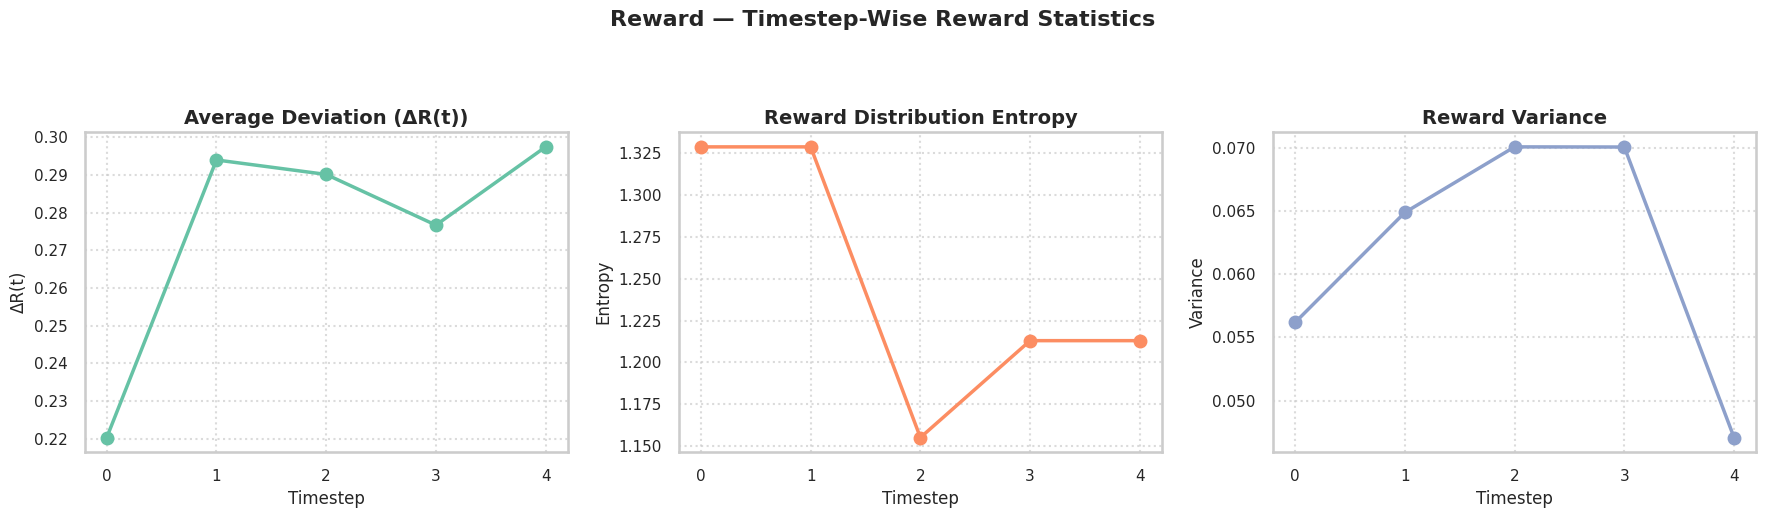

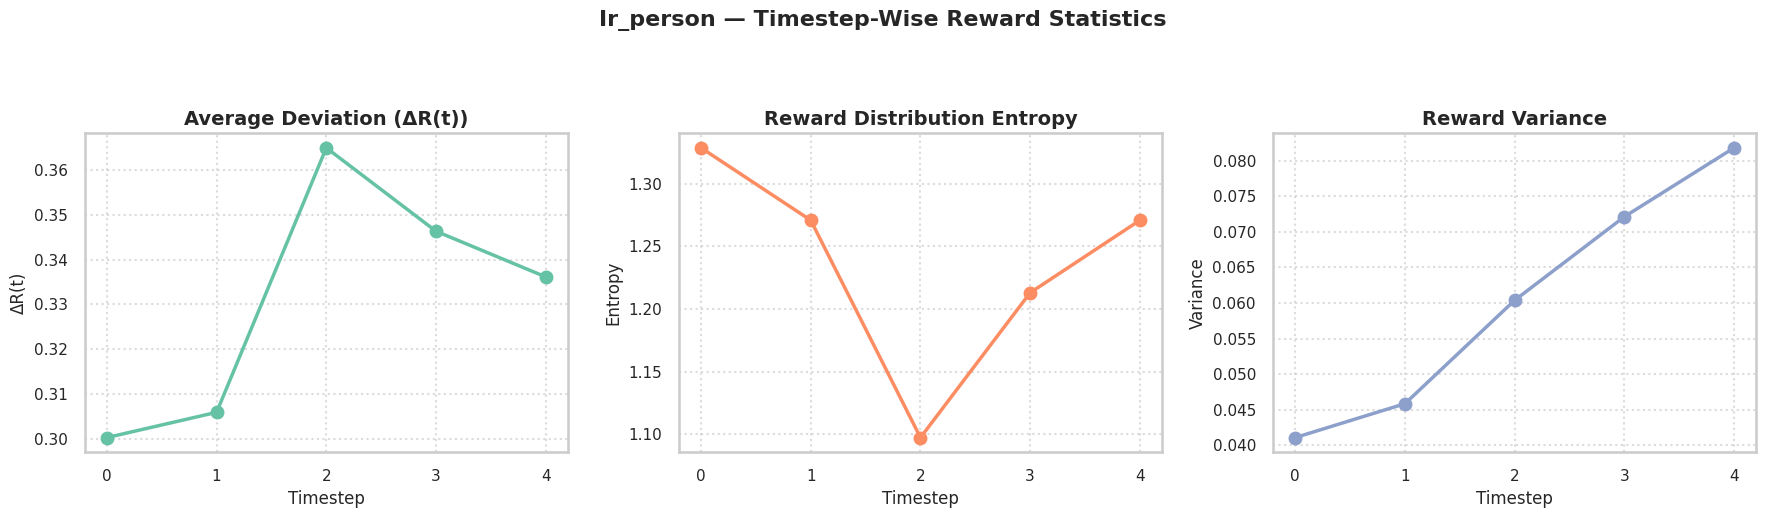

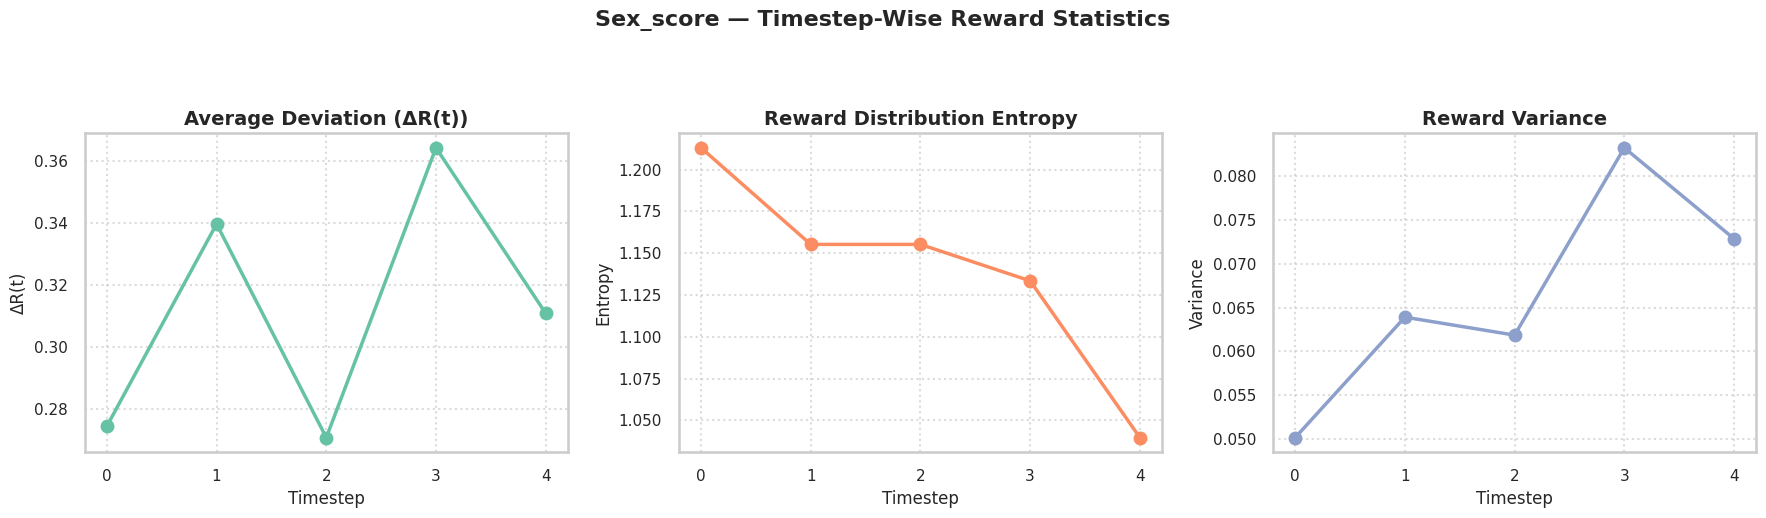

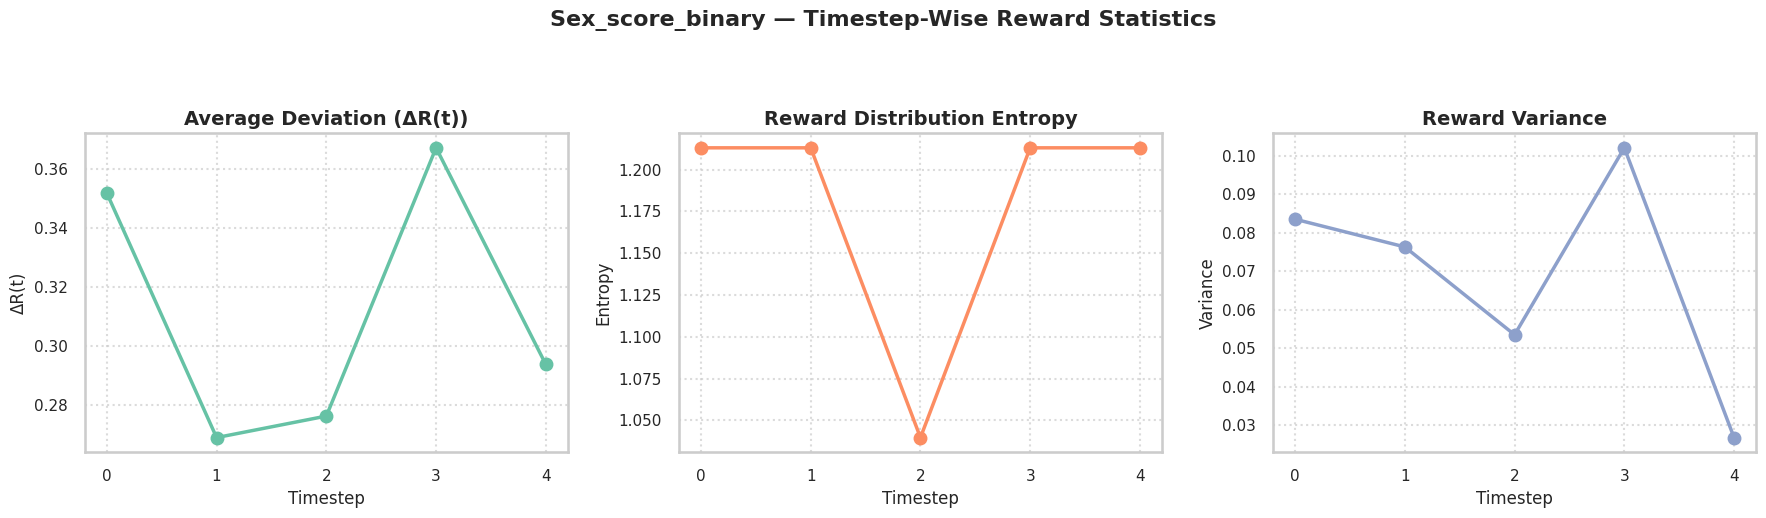

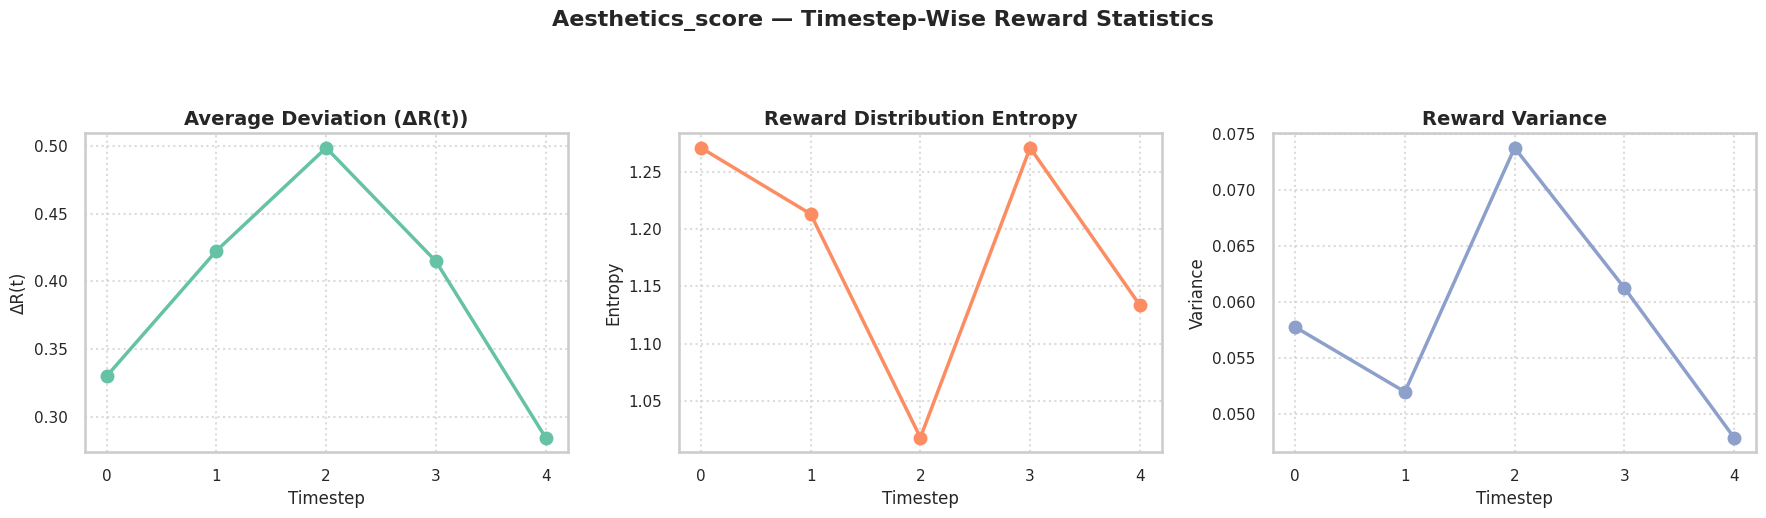

In [37]:
sns.set(style="whitegrid", context="talk")

# Get all unique timesteps in sorted order
timesteps = sorted(all_data["timestep"].dropna().unique().astype(int))

for metric in METRICS:
    # Compute the three metrics for this metric column
    delta_values = [avg_deviation_at_timestep(all_data, timestep=t, metric_col=metric) for t in timesteps]
    entropy_values = [entropy_at_timestep(all_data, timestep=t, metric_col=metric, num_bins=10) for t in timesteps]
    variance_values = [variance_at_timestep(all_data, timestep=t, metric_col=metric) for t in timesteps]

    delta_values = np.array(delta_values)
    entropy_values = np.array(entropy_values)
    variance_values = np.array(variance_values)

    # Consistent color palette
    colors = sns.color_palette("Set2", 3)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    # --- ΔR(t): Average Deviation ---
    axes[0].plot(timesteps, delta_values, marker="o", linewidth=2.5, color=colors[0])
    axes[0].set_title("Average Deviation (ΔR(t))", fontsize=14, fontweight="semibold")
    axes[0].set_ylabel("ΔR(t)", fontsize=12)
    axes[0].grid(True, alpha=0.7, linestyle=":")

    # --- Entropy ---
    axes[1].plot(timesteps, entropy_values, marker="o", linewidth=2.5, color=colors[1])
    axes[1].set_title("Reward Distribution Entropy", fontsize=14, fontweight="semibold")
    axes[1].set_ylabel("Entropy", fontsize=12)
    axes[1].grid(True, alpha=0.7, linestyle=":")

    # --- Variance ---
    axes[2].plot(timesteps, variance_values, marker="o", linewidth=2.5, color=colors[2])
    axes[2].set_title("Reward Variance", fontsize=14, fontweight="semibold")
    axes[2].set_ylabel("Variance", fontsize=12)
    axes[2].grid(True, alpha=0.7, linestyle=":")

    # Shared x-axis label and formatting
    for ax in axes:
        ax.set_xlabel("Timestep", fontsize=12)
        ax.tick_params(axis="both", labelsize=11)
        ax.set_xticks(timesteps)  # ensure integer ticks
        ax.set_xticklabels(timesteps, rotation=0)
    
    # Global figure title
    fig.suptitle(f"{metric.capitalize()} — Timestep-Wise Reward Statistics", fontsize=16, fontweight="bold", y=1.05)

    plt.tight_layout()
    plt.show()


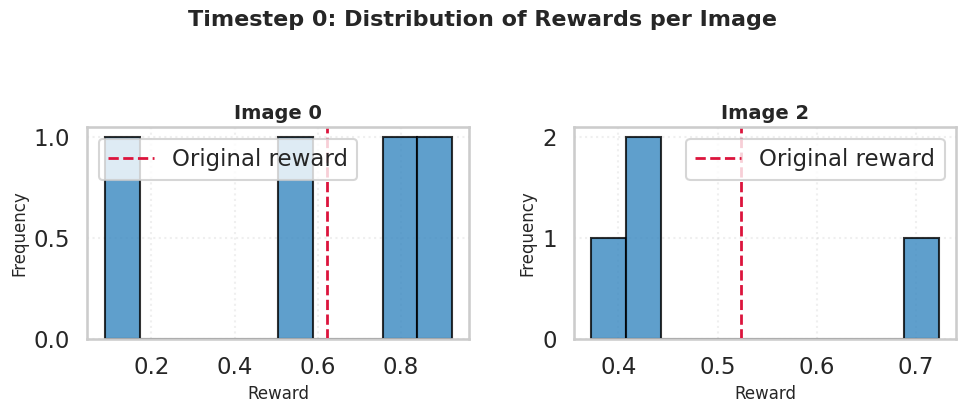

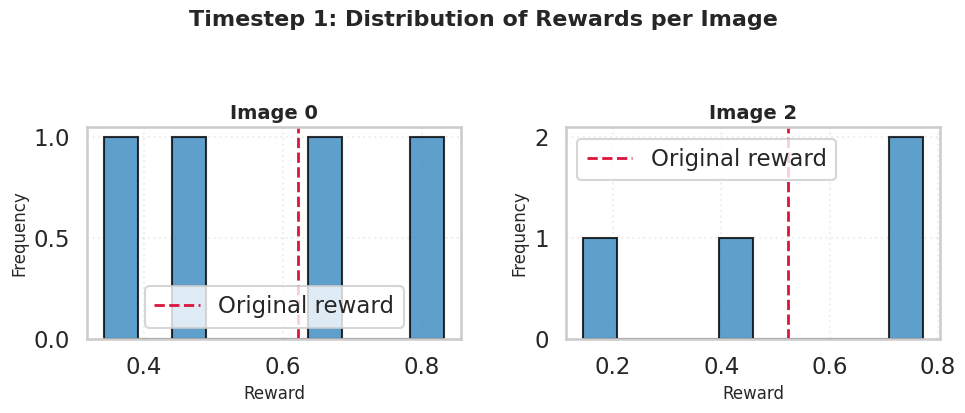

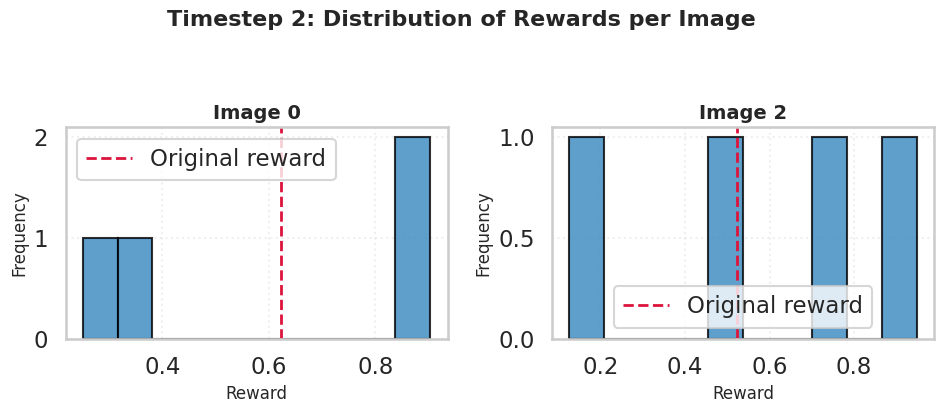

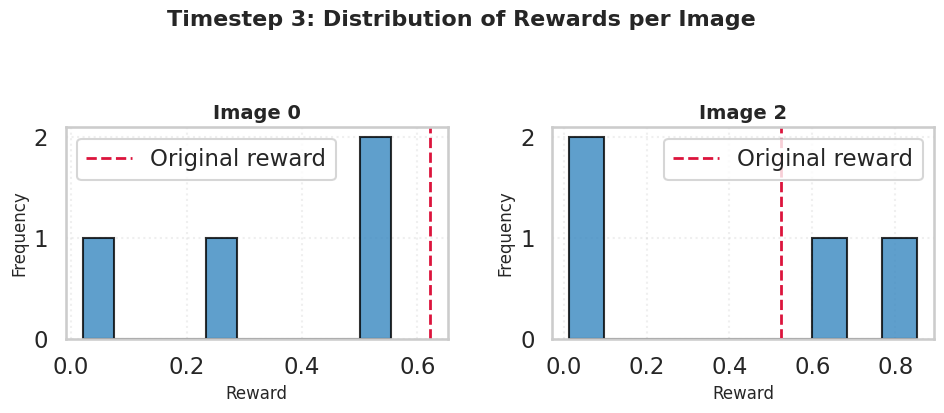

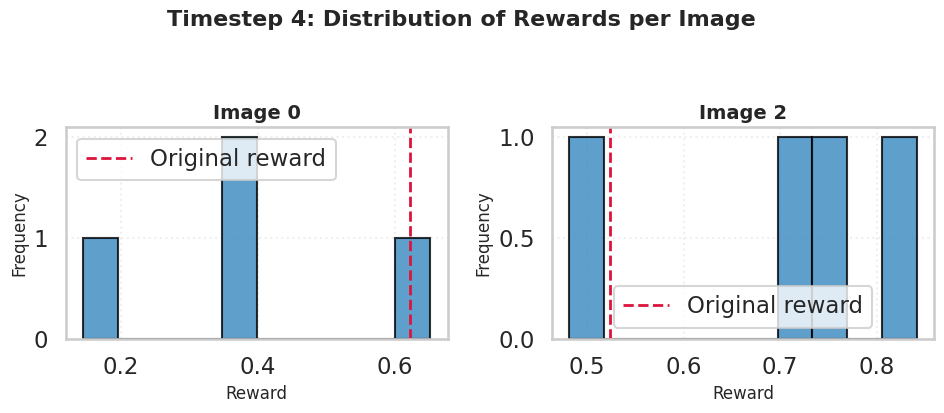

In [33]:
# Plot histograms for all timesteps with original reward marked
plot_reward_histograms_with_original(all_data, metric_col="reward", bins=10, image_idxs=[0, 2])


In [34]:
make_reconstruction_gif(worker_id=0, image_id=0, plot_dir=BASE_DIR, timesteps=timesteps, num_samples=20)

GIF saved to /home/amanda/Desktop/Fine-Tuning-Diffusion-Models-With-RL/dummy_workers/worker_0/image_0_recon.gif


'/home/amanda/Desktop/Fine-Tuning-Diffusion-Models-With-RL/dummy_workers/worker_0/image_0_recon.gif'